## Ejercicio de Programación 5 - Reconstrucción de imagen usando Gradiente Conjugado


1. Construir matriz de transformación A
2. Implementar algoritmo de gradiente conjugado no lineal
3. Calcular función objetivo chi-cuadrado
4. Aplicar regularización si es necesario
5. Reconstruir imagen y visualizar resultados
6. Comparar con imagen verdadera y evaluar convergencia

In [331]:
%reload_ext autoreload
%autoreload 2

In [381]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

#imports
import numpy as np
from modules.backend import xp

# modules
from modules.simulation import visibilities_simulation
from modules.plots import plot_uv_coverage_2, plot_sources
from modules.optimization import l1, tsv, entropy, ncg_optimize, plot_stats
from modules.gridder import grid_visibilities, get_grid_config
from modules.interferometry import get_dirty_image, restore_image, forward_op, adjoint_op
from modules.plots import plot


In [333]:
# simulate visibilities no grid
VLA_L_4 = {
  "latitude": 34.078749,
  "longitude": -107.617728,
  "file_route": "../antenna_arrays/vla.a.cfg",
  "catalog_source": "LMC",
  "utc_start": "2025-10-10T00:00:00",
  "utc_end": "2025-10-10T12:00:00",
  "step_min": 5,
  "n_freqs": 4,
  "interferometer": {
    "name": "VLA",
    "band_name": "L" },
  "n_sources": 10,
  "max_offset_deg": 0.1,
  "flux_range": [5.0, 5.0],
  "seed":42
  }

V, uvw, uvw_lambda, [frequencies, channel_bandwidth], baselines_enu, sources , [l,m,n] , times_sec = visibilities_simulation(VLA_L_4)

# plot_uv_coverage_2(uvw, 512, title="test")

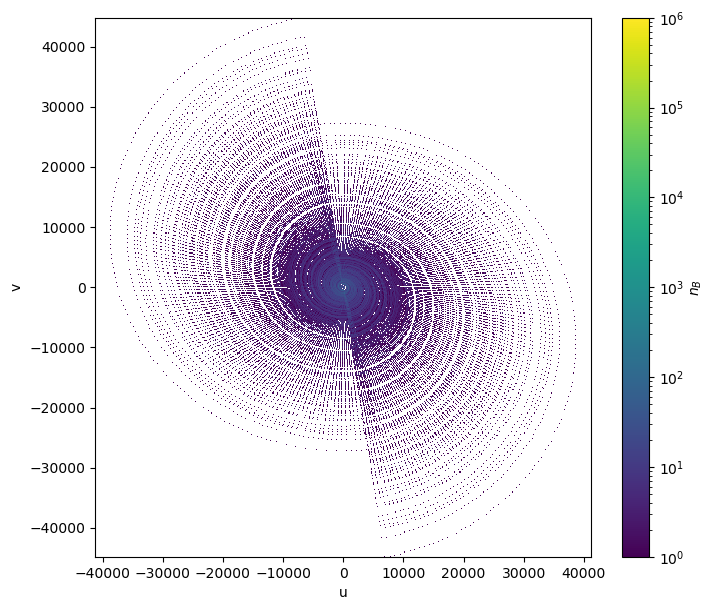

In [334]:
plot_uv_coverage_2(uvw, bins=512)

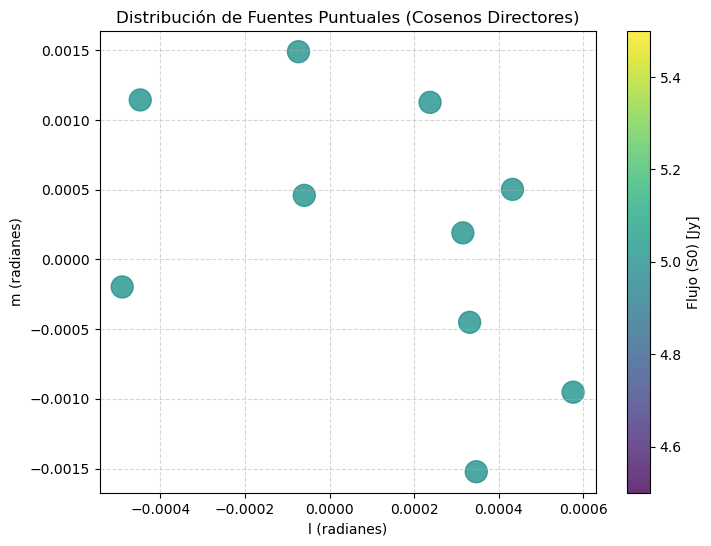

In [335]:
plot_sources(l,m,sources)

In [ ]:
N = 512
grid_config = get_grid_config(V, uvw_lambda, N, 
                              baselines=baselines_enu,
                              oversampling_factor=3, 
                              frequencies=frequencies)
grid_config.keys()

dict_keys(['V', 'uvw_lambda', 'du', 'dv', 'Dmax', 'frequencies', 'oversampling_factor', 'baselines', 'Npix', 'pixel_size_image'])

In [348]:
grid_config["pixel_size_image"] = 1

In [349]:
VG, WG = grid_visibilities(grid_config=grid_config, mode="numpy")

Backend a utilizar: numpy


In [ ]:
# todas las imagenes serán reconstruidas a partir de una imagen en 0 de dimensión (N,N)
Img_init = xp.zeros((N,N))

# Lambda regularization
dirty_image = get_dirty_image(VG)

lambda_reg = 0.1 * xp.max(xp.abs(dirty_image))

print('lambda_reg:',lambda_reg)

lambda_reg: 0.07282006


Generating plot with scale: 5 (Figure size: 5.0x5.0 inches)


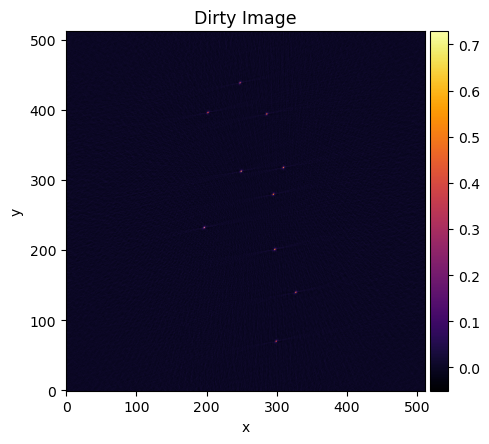

In [ ]:
plot_dirty = [
    {'image':dirty_image, 'title':'Dirty Image', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
]

plot(fig_title='', data=plot_dirty, grid_config=(1,1), scale=5)

# Optimization

## L1

In [406]:
args =(VG, WG, lambda_reg, l1)

I_model_l1, info = ncg_optimize(
    x0=Img_init,
    args=args,
    gtol=1e-6,
    ftol=1e-10,
    verbose=True,
    max_iter=200
)

[NCG] it=0 cost=1.725768e+07 ||g||=1.892e+01
[NCG] it=1 cost=1.385503e+07 ||g||=5.261e+01 alpha=5.00e-01 beta=7.73e+00
[NCG] it=2 cost=5.218486e+06 ||g||=4.130e+01 alpha=1.25e-01 beta=6.16e-01
[NCG] it=3 cost=5.153310e+06 ||g||=4.112e+01 alpha=1.00e-03 beta=9.91e-01
[NCG] it=4 cost=3.779076e+06 ||g||=3.609e+01 alpha=3.12e-02 beta=7.71e-01
[NCG] it=5 cost=3.783260e+06 ||g||=3.604e+01 alpha=1.00e-03 beta=9.97e-01
[NCG] it=6 cost=3.787991e+06 ||g||=3.598e+01 alpha=1.00e-03 beta=9.97e-01
[NCG] it=7 cost=3.793323e+06 ||g||=3.593e+01 alpha=1.00e-03 beta=9.97e-01
[NCG] it=8 cost=3.799126e+06 ||g||=3.587e+01 alpha=1.00e-03 beta=9.97e-01
[NCG] it=9 cost=3.805479e+06 ||g||=3.582e+01 alpha=1.00e-03 beta=9.97e-01
[NCG] it=10 cost=3.812360e+06 ||g||=3.577e+01 alpha=1.00e-03 beta=9.97e-01
[NCG] it=11 cost=3.819685e+06 ||g||=3.572e+01 alpha=1.00e-03 beta=9.97e-01
[NCG] it=12 cost=3.827506e+06 ||g||=3.567e+01 alpha=1.00e-03 beta=9.97e-01
[NCG] it=13 cost=3.835826e+06 ||g||=3.562e+01 alpha=1.00e-03 bet

In [407]:
I_restored_l1, I_resid_l1, beam_l1 = restore_image(
    I_model=I_model_l1,
    V_obs=VG,
    weights=WG,
    uvw_lambda=uvw_lambda,
    pixel_size=grid_config['pixel_size_image'],
    forward_op=forward_op,
    adjoint_op=adjoint_op
)

Generating plot with scale: 5 (Figure size: 15.0x10.0 inches)


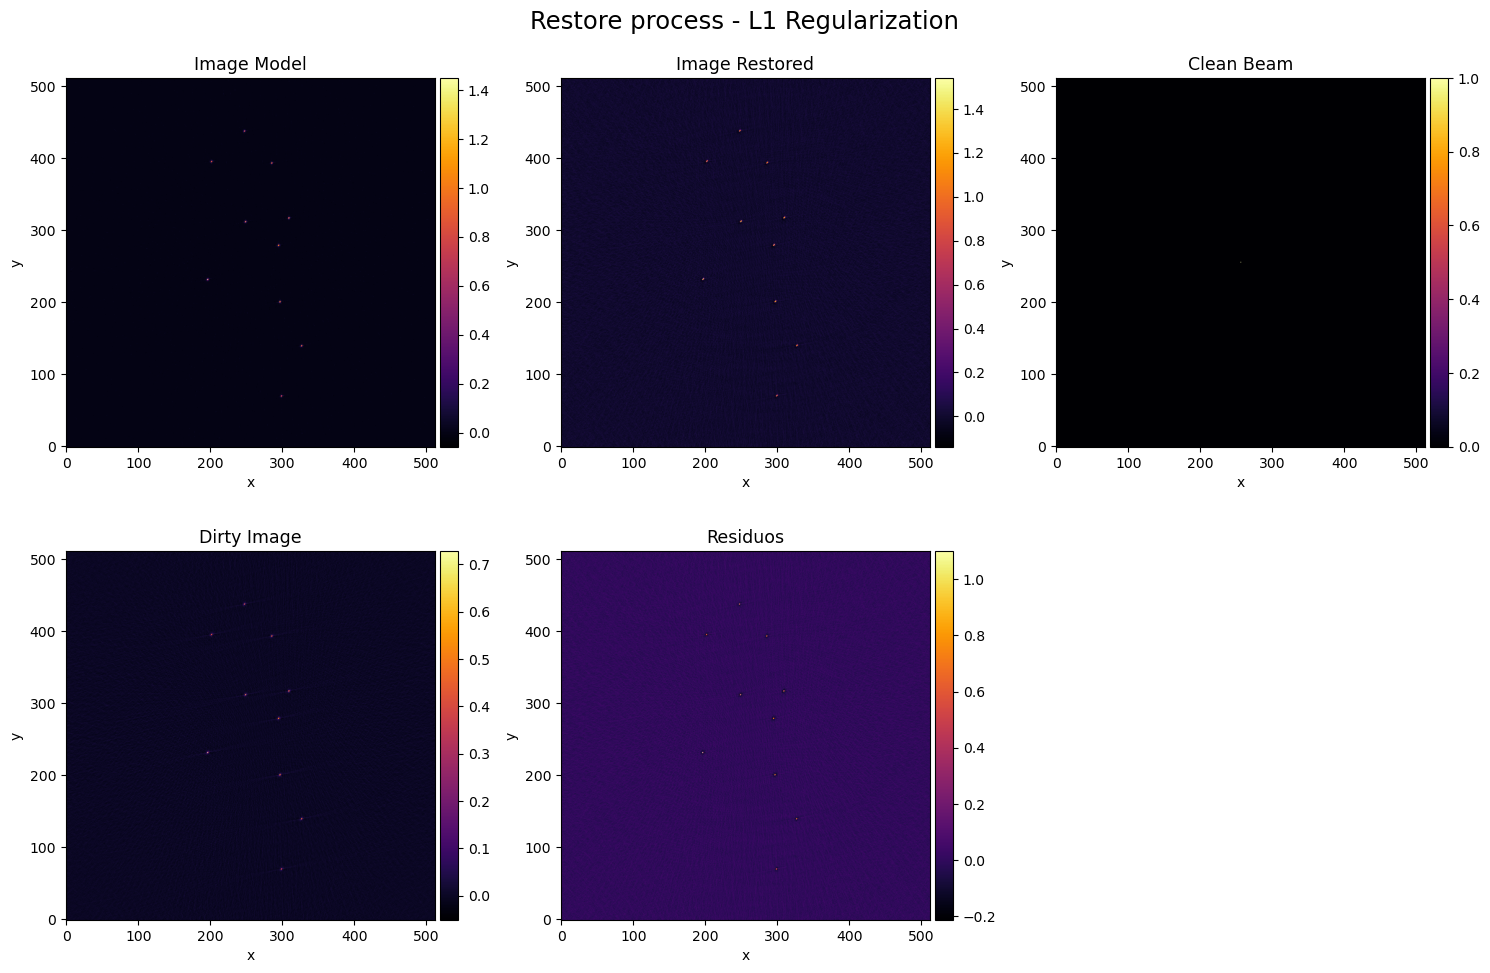

In [408]:
plot_l1 = [
    {'image':I_model_l1, 'title':'Image Model', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
    {'image':I_restored_l1.real, 'title':'Image Restored', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
    {'image':beam_l1, 'title':'Clean Beam', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
    {'image':dirty_image, 'title':'Dirty Image', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
    {'image':I_resid_l1, 'title':'Residuos', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
]

plot(fig_title='Restore process - L1 Regularization', data=plot_l1, grid_config=(2,3), scale=5)

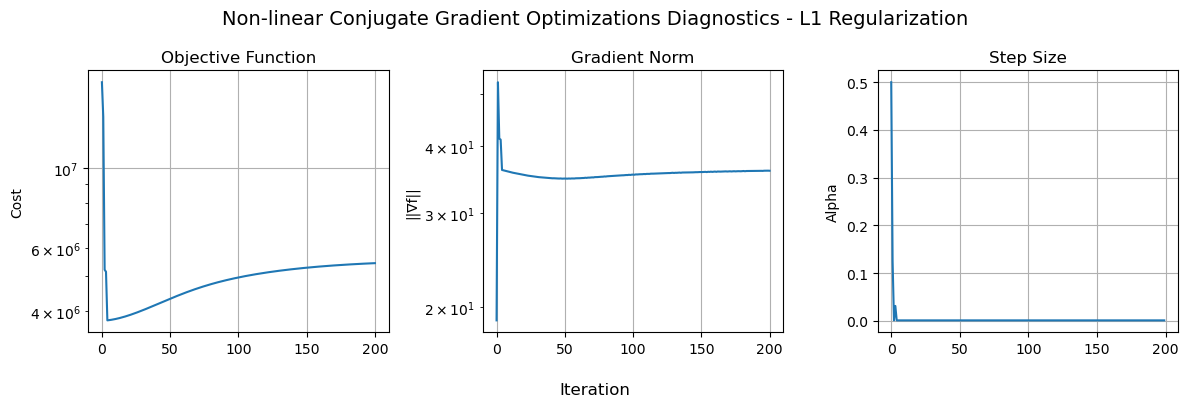

In [409]:
plot_stats(info, "Non-linear Conjugate Gradient Optimizations Diagnostics - L1 Regularization")

## TSV


In [410]:
args =(VG, WG, lambda_reg, tsv)

I_model_tsv, info_tsv = ncg_optimize(
    x0=Img_init,
    args=args,
    gtol=1e-6,
    ftol=1e-10,
    verbose=True,
    max_iter=200
)


[NCG] it=0 cost=1.725768e+07 ||g||=1.892e+01
[NCG] it=1 cost=1.385482e+07 ||g||=2.576e+01 alpha=5.00e-01 beta=1.85e+00
[NCG] it=2 cost=1.365540e+07 ||g||=2.424e+01 alpha=6.25e-02 beta=8.86e-01
[NCG] it=3 cost=8.142455e+06 ||g||=1.920e+01 alpha=1.25e-01 beta=6.28e-01
[NCG] it=4 cost=5.402308e+06 ||g||=1.625e+01 alpha=1.25e-01 beta=7.16e-01
[NCG] it=5 cost=3.350861e+06 ||g||=1.246e+01 alpha=1.25e-01 beta=5.88e-01
[NCG] it=6 cost=2.556100e+06 ||g||=9.434e+00 alpha=1.25e-01 beta=5.73e-01
[NCG] it=7 cost=2.080364e+06 ||g||=7.355e+00 alpha=1.25e-01 beta=6.08e-01
[NCG] it=8 cost=1.730705e+06 ||g||=5.546e+00 alpha=1.25e-01 beta=5.69e-01
[NCG] it=9 cost=1.433557e+06 ||g||=4.271e+00 alpha=1.25e-01 beta=5.93e-01
[NCG] it=10 cost=1.200680e+06 ||g||=3.211e+00 alpha=1.25e-01 beta=5.65e-01
[NCG] it=11 cost=1.162612e+06 ||g||=4.075e+00 alpha=2.50e-01 beta=1.61e+00
[NCG] it=12 cost=9.093490e+05 ||g||=1.647e+00 alpha=1.25e-01 beta=1.63e-01
[NCG] it=13 cost=9.062267e+05 ||g||=1.783e+00 alpha=2.50e-01 bet

In [411]:
I_restored_tsv, I_resid_tsv, beam_tsv = restore_image(
    I_model=I_model_tsv,
    V_obs=VG,
    weights=WG,
    uvw_lambda=uvw_lambda,
    pixel_size=grid_config['pixel_size_image'],
    forward_op=forward_op,
    adjoint_op=adjoint_op
)

Generating plot with scale: 5 (Figure size: 15.0x10.0 inches)


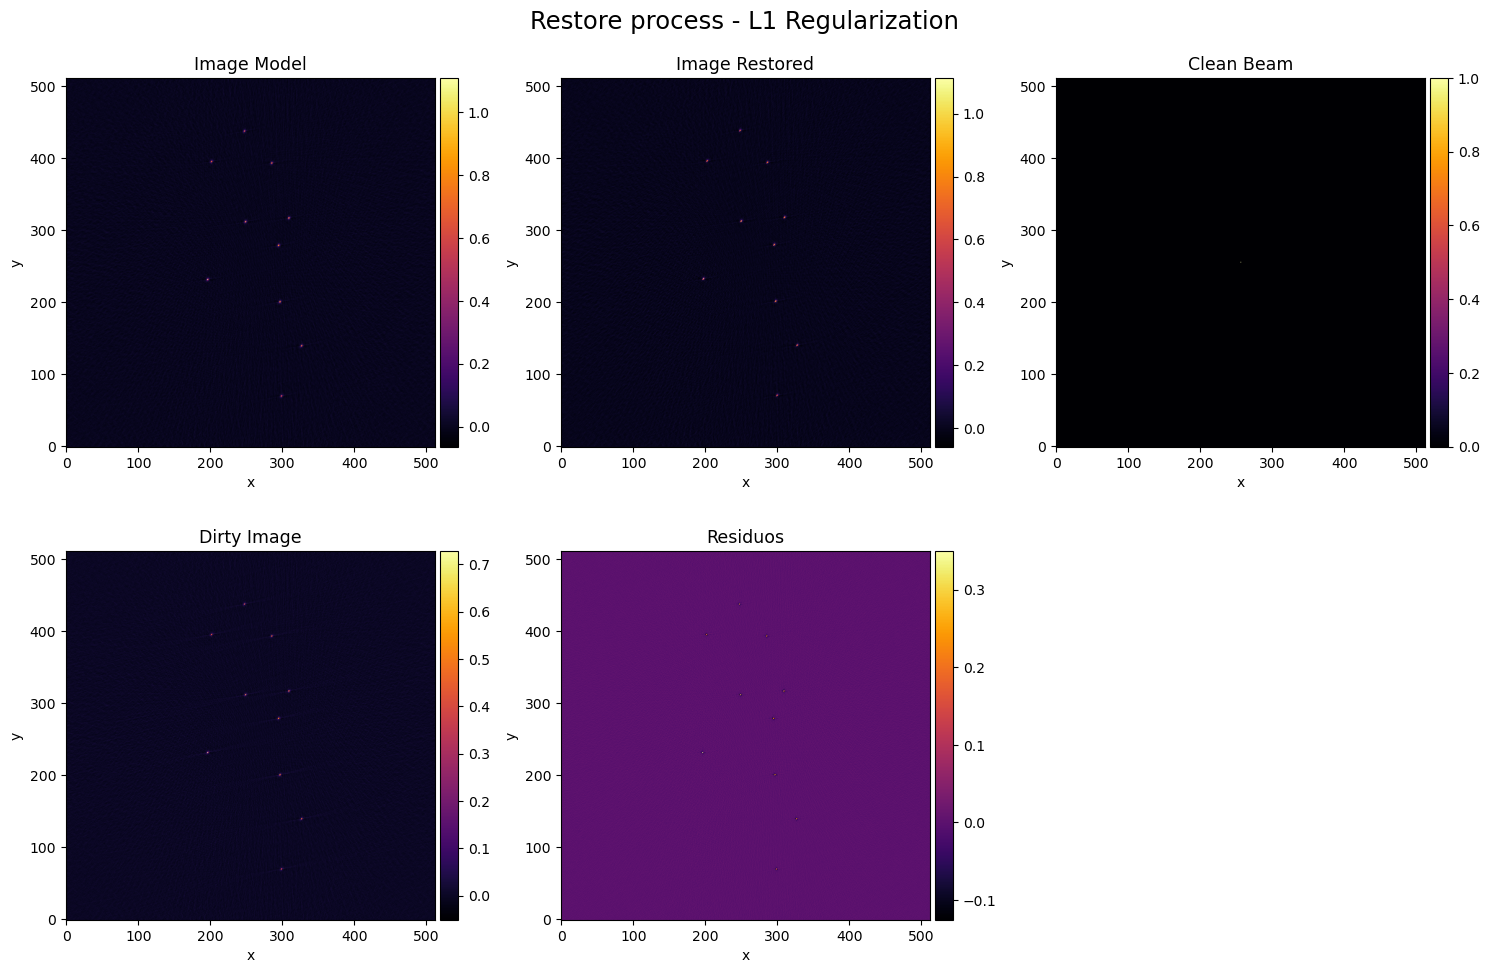

In [412]:
plot_tsv = [
    {'image':I_model_tsv, 'title':'Image Model', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
    {'image':I_restored_tsv.real, 'title':'Image Restored', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
    {'image':beam_tsv, 'title':'Clean Beam', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
    {'image':dirty_image, 'title':'Dirty Image', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
    {'image':I_resid_tsv, 'title':'Residuos', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
]

plot(fig_title='Restore process - L1 Regularization', data=plot_tsv, grid_config=(2,3), scale=5)

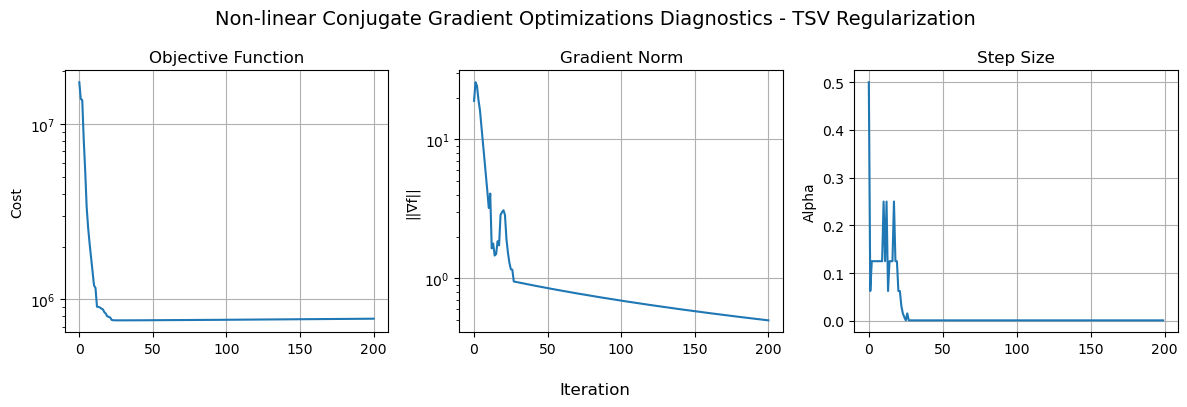

In [413]:
plot_stats(info_tsv, title="Non-linear Conjugate Gradient Optimizations Diagnostics - TSV Regularization")

## Entropy

In [399]:
args =(VG, WG, lambda_reg, entropy)

I_model_en, info = ncg_optimize(
    x0=Img_init,
    args=args,
    gtol=1e-6,
    ftol=1e-10,
    verbose=False,
    max_iter=300
)


In [400]:
I_restored_en, I_resid_en, beam_en = restore_image(
    I_model=I_model_en,
    V_obs=VG,
    weights=WG,
    uvw_lambda=uvw_lambda,
    pixel_size=grid_config['pixel_size_image'],
    forward_op=forward_op,
    adjoint_op=adjoint_op
)

Generating plot with scale: 5 (Figure size: 15.0x10.0 inches)


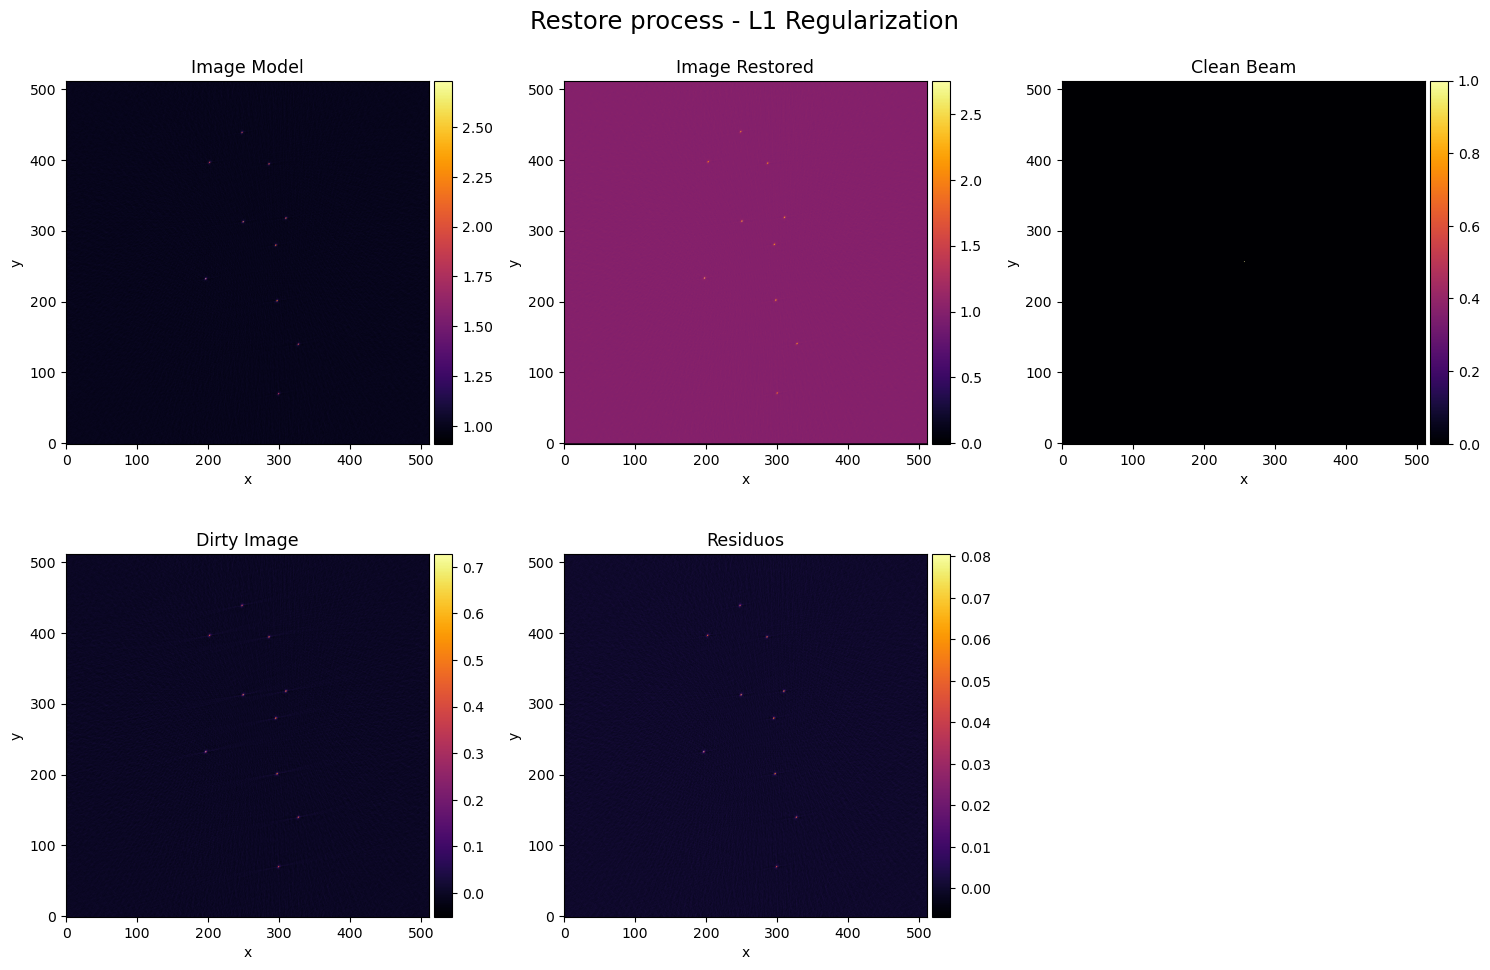

In [403]:
plot_en = [
    {'image':I_model_en, 'title':'Image Model', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
    {'image':I_restored_en.real, 'title':'Image Restored', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
    {'image':beam_en, 'title':'Clean Beam', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
    {'image':dirty_image, 'title':'Dirty Image', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
    {'image':I_resid_en, 'title':'Residuos', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
]

plot(fig_title='Restore process - L1 Regularization', data=plot_en, grid_config=(2,3), scale=5)

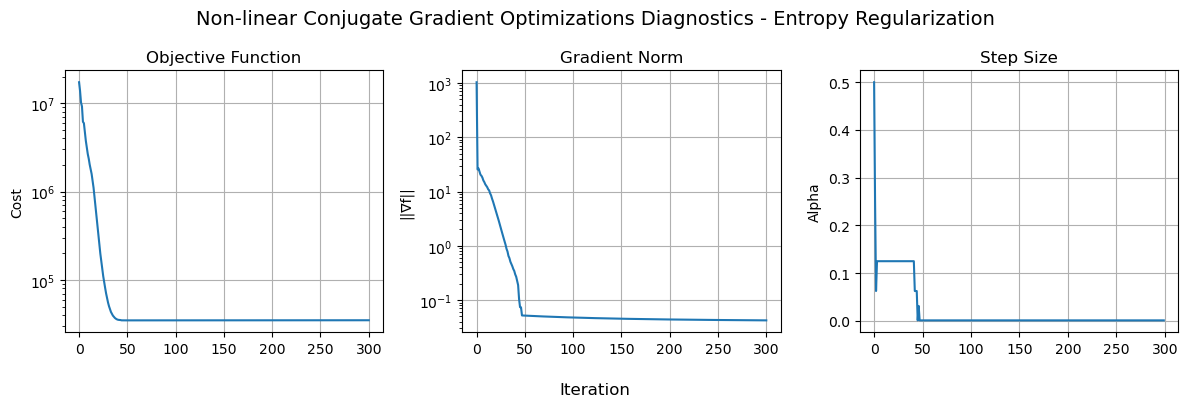

In [402]:
plot_stats(info, title="Non-linear Conjugate Gradient Optimizations Diagnostics - Entropy Regularization")